# 🫁 Classification des Sons Respiratoires — AST + SAM + Focal Loss

Ce notebook présente un pipeline complet du projet ICBHI-AST-SAM :
1. Prétraitement des données ICBHI 2017
2. Définition du modèle (AST + SAM + Focal Loss)
3. Entraînement (fine-tuning) 
4. Évaluation 

In [1]:
!pip install transformers -q

##  2.Configuration

In [2]:
import os
import gc
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import ASTModel, ASTFeatureExtractor
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


IS_KAGGLE = os.path.exists("/kaggle")

if IS_KAGGLE:
    WORK_DIR = "/kaggle/working/icbhi_ast_sam"
else:
    WORK_DIR = "./outputs"

CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env_name = "Kaggle" if IS_KAGGLE else "Local"
print(f"Environnement : {env_name}")
print(f"Device        : {DEVICE}")
print(f"WORK_DIR      : {WORK_DIR}")
print(f"CHECKPOINT_DIR: {CHECKPOINT_DIR}")

Environnement : Kaggle
Device        : cuda
WORK_DIR      : /kaggle/working/icbhi_ast_sam
CHECKPOINT_DIR: /kaggle/working/icbhi_ast_sam/checkpoints


##  3. Prétraitement

### 3.1 Constantes et fonctions utilitaires
- **16 kHz** : fréquence d'échantillonnage attendue par AST
- **8 secondes** : durée fixe pour chaque cycle
- **Cyclic Padding** : on répète le signal au lieu d'ajouter des zéros

In [ ]:
TARGET_SR = 16000
TARGET_DURATION = 8
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION

DEVICE_MAP = {'AKGC417L': 0, 'LittC2SE': 1, 'Litt3200': 2, 'Meditron': 3}

def get_device_id(filename):
    dev_name = filename.split('_')[-1]
    return DEVICE_MAP.get(dev_name, -1)

def cyclic_padding(wav, target_len):
    if len(wav) >= target_len:
        return wav[:target_len]
    repeat_count = (target_len // len(wav)) + 1
    return np.tile(wav, repeat_count)[:target_len]


### 3.2 Traitement des données

Pour chaque enregistrement :
1. Charger le .wav à 16kHz
2. Lire les annotations .txt (cycles respiratoires)
3. Découper chaque cycle + cyclic padding à 8s
4. Assigner le label (0:Normal, 1:Crackle, 2:Wheeze, 3:Both)

In [ ]:
import librosa

DATA_DIR = "./data/ICBHI_final_database"
SPLIT_FILE = "./data/ICBHI_Challenge_train_test.txt"

def process_data():
    split_df = pd.read_csv(SPLIT_FILE, sep='\t', names=['filename', 'set_type'])
    X_train, y_train, device_train = [], [], []
    X_test, y_test, device_test = [], [], []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        fname, set_type = row['filename'], row['set_type']
        wav_path = os.path.join(DATA_DIR, fname + '.wav')
        txt_path = os.path.join(DATA_DIR, fname + '.txt')
        if not os.path.exists(wav_path) or not os.path.exists(txt_path):
            continue
        audio, _ = librosa.load(wav_path, sr=TARGET_SR)
        dev_id = get_device_id(fname)
        anns = pd.read_csv(txt_path, sep='\t', names=['start', 'end', 'crackle', 'wheeze'])
        for _, ann in anns.iterrows():
            start = int(ann['start'] * TARGET_SR)
            end = int(ann['end'] * TARGET_SR)
            chunk = audio[start:end]
            if len(chunk) < 100:
                continue
            processed_wav = cyclic_padding(chunk, TARGET_SAMPLES)
            c, w = ann['crackle'], ann['wheeze']
            if c == 0 and w == 0: label = 0
            elif c == 1 and w == 0: label = 1
            elif c == 0 and w == 1: label = 2
            else: label = 3
            if set_type == 'train':
                X_train.append(processed_wav)
                y_train.append(label)
                device_train.append(dev_id)
            else:
                X_test.append(processed_wav)
                y_test.append(label)
                device_test.append(dev_id)
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int64),
            np.array(device_train, dtype=np.int64), np.array(X_test, dtype=np.float32),
            np.array(y_test, dtype=np.int64), np.array(device_test, dtype=np.int64))


INPUT_NPZ = "/kaggle/input/icbhi-ast-sam-data/icbhi_preprocessed.npz"
WORK_NPZ = f"{WORK_DIR}/icbhi_preprocessed.npz"

if os.path.exists(WORK_NPZ):
    data = np.load(WORK_NPZ)
    print("NPZ charge depuis working")
elif os.path.exists(INPUT_NPZ):
    shutil.copy(INPUT_NPZ, WORK_NPZ)
    data = np.load(WORK_NPZ)
    print("NPZ copie depuis input")
else:
    print("Pretraitement en cours...")
    X_train, y_train, d_train, X_test, y_test, d_test = process_data()
    np.savez(WORK_NPZ, X_train=X_train, y_train=y_train, d_train=d_train,
             X_test=X_test, y_test=y_test, d_test=d_test)
    data = np.load(WORK_NPZ)
    print("Pretraitement termine et sauvegarde")


In [4]:
NPZ_PATH = "/kaggle/input/datasets/roumaissafezai/dataset/icbhi_preprocessed.npz"

import numpy as np
data    = np.load(NPZ_PATH)
X_train = data['X_train']
y_train = data['y_train']
d_train = data['d_train']
X_test  = data['X_test']
y_test  = data['y_test']
d_test  = data['d_test']

print(f" Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribution: {np.bincount(y_train)}")

 Train: (4131, 128000), Test: (2756, 128000)
Distribution: [2057 1210  501  363]


##  4. Définition du Modèle

### 4.1 Optimiseur SAM (Sharpness-Aware Minimization)

In [6]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(torch.stack([
            ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"]
            if p.grad is not None
        ]), p=2)
        return norm

### 4.2 Focal Loss

Remplace CrossEntropyLoss pour mieux gerer le desequilibre de classes ICBHI.
gamma=2 : penalise les erreurs sur les exemples difficiles.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

### 5.1 Dataset PyTorch
Convertit les wav bruts en spectrogrammes via ASTFeatureExtractor.
Applique une augmentation légère (gain + bruit) pendant l'entraînement.

In [8]:
class ASTDataset(Dataset):
    def __init__(self, X, y, device_ids, processor, train=True):
        self.X, self.y, self.device_ids = X, y, device_ids
        self.processor, self.train = processor, train

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        wav = self.X[idx]
        if self.train:
            if np.random.random() < 0.5:
                wav = wav * np.random.uniform(0.9, 1.1)
            if np.random.random() < 0.5:
                wav = wav + np.random.normal(0, 0.0001, wav.shape)
        inputs = self.processor(wav, sampling_rate=16000, return_tensors="pt")
        input_values = inputs.input_values.squeeze(0)
        return input_values, torch.tensor(self.y[idx], dtype=torch.long), self.device_ids[idx]

### 4.3 CustomAST
AST pré-entraîné sur AudioSet + nouvelle tête de classification à 4 classes.
Mean Pooling sur tous les patches du spectrogramme.

In [9]:
class CustomAST(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        outputs = self.ast(x)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(embeddings)

##  5. Entrainement
- **SAM + AdamW** : optimiseur avec 2 passes par batch
- **WeightedRandomSampler** : compense le déséquilibre des classes
- **Label Smoothing** : empêche le modèle d'être trop confiant
- Le meilleur modèle (ICBHI Score) est sauvegardé automatiquement

In [13]:
EPOCHS = 20
BATCH_SIZE = 8
LR = 1e-5

processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
counts  = np.bincount(y_train)
weights = [1.0/counts[y] for y in y_train]
sampler = WeightedRandomSampler(weights, len(y_train))
train_loader = DataLoader(ASTDataset(X_train, y_train, d_train, processor, train=True), batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(ASTDataset(X_test, y_test, d_test, processor, train=False), batch_size=BATCH_SIZE, shuffle=False)


model = CustomAST(num_classes=4)
if torch.cuda.device_count() > 1:
    print(f"{torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
model = model.to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, rho=0.05, weight_decay=1e-4)
criterion = FocalLoss(gamma=2.0)

RESUME_PATH = os.path.join(CHECKPOINT_DIR, "resume_checkpoint.pth")
BEST_PATH   = os.path.join(CHECKPOINT_DIR, "best_model.pth")
start_epoch = 0
best_score  = 0.0

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"])
    start_epoch = ckpt["epoch"] + 1
    best_score  = ckpt["best_score"]
    print(f"Reprise depuis epoch {start_epoch + 1}/{EPOCHS} | Score: {best_score:.4f}")
else:
    print(f"Nouveau depart : {sum(p.numel() for p in model.parameters())/1e6:.1f}M parametres")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2 GPUs!
Nouveau depart : 86.2M parametres


In [ ]:
for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for inputs, labels, _ in progress:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)
        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)
        running_loss += loss.item()
        progress.set_postfix({'Loss': loss.item()})

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            preds = torch.argmax(model(inputs.to(DEVICE)), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm    = confusion_matrix(all_labels, all_preds)
    se    = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :]) if np.sum(cm[1:, :]) > 0 else 0
    sp    = cm[0, 0] / np.sum(cm[0, :]) if np.sum(cm[0, :]) > 0 else 0
    score = (se + sp) / 2
    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | Se={se:.4f} | Sp={sp:.4f} | Score={score:.4f}")

    if score > best_score:
        best_score = score
        torch.save(model.state_dict(), BEST_PATH)
        print(f"Meilleur modele sauvegarde ({best_score:.4f})")
    torch.save({"epoch": epoch, "model": model.state_dict(), "best_score": best_score}, RESUME_PATH)
    # 3. Chaque epoch
    torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/model_epoch_{epoch+1}.pt")
print(f"\nMeilleur Score: {best_score:.4f}")

Epoch 1: Loss=0.4346 | Se=0.9533 | Sp=0.1634 | Score=0.5583
Meilleur modele sauvegarde (0.5583)


Epoch 2: Loss=0.2663 | Se=0.6474 | Sp=0.6035 | Score=0.6255
Meilleur modele sauvegarde (0.6255)


Epoch 3: Loss=0.2022 | Se=0.6075 | Sp=0.6618 | Score=0.6346
Meilleur modele sauvegarde (0.6346)


Epoch 4: Loss=0.1503 | Se=0.8624 | Sp=0.3521 | Score=0.6072


Epoch 5: Loss=0.1202 | Se=0.6602 | Sp=0.6168 | Score=0.6385
Meilleur modele sauvegarde (0.6385)


...

Epoch 13: Loss=0.0306 | Se=0.6075 | Sp=0.7258 | Score=0.6666


Epoch 14: Loss=0.0286 | Se=0.6457 | Sp=0.6529 | Score=0.6493


Epoch 15: Loss=0.0251 | Se=0.6576 | Sp=0.6498 | Score=0.6537


Epoch 16: Loss=0.0262 | Se=0.5590 | Sp=0.7492 | Score=0.6541


Epoch 17/20:  68%|██████▊   | 352/517 [14:52<06:58,  2.54s/it, Loss=0.00951] 

## 📊 7. Évaluation Finale

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sensitivity (Se): 57.52%
Specificity (Sp): 77.39%
ICBHI Score:       67.45%


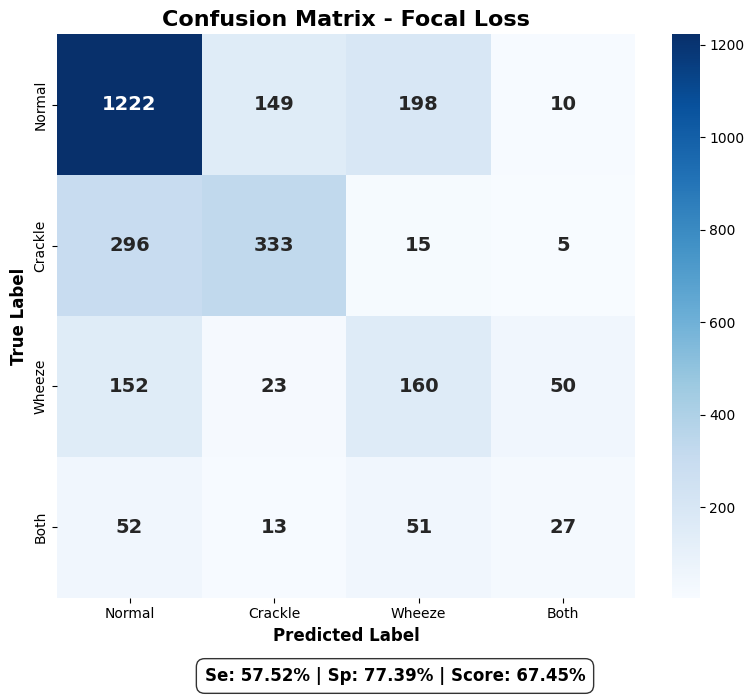

In [16]:
gc.collect()
torch.cuda.empty_cache()
model = CustomAST(num_classes=4).to(DEVICE)
state_dict = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.eval()

CLASSES = ['Normal', 'Crackle', 'Wheeze', 'Both']
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, labels, _ in test_loader:
        inputs = inputs.to(DEVICE)
        if DEVICE.type == 'cuda':
            with torch.amp.autocast('cuda'):
                preds = torch.argmax(model(inputs), dim=1)
        else:
            preds = torch.argmax(model(inputs), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

cm = confusion_matrix(all_targets, all_preds)
se = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :])
sp = cm[0, 0] / np.sum(cm[0, :])
score = (se + sp) / 2

print(f"Sensitivity (Se): {se*100:.2f}%")
print(f"Specificity (Sp): {sp*100:.2f}%")
print(f"ICBHI Score:       {score*100:.2f}%")

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Focal Loss', fontsize=16, fontweight='bold')
metrics_text = f"Se: {se*100:.2f}% | Sp: {sp*100:.2f}% | Score: {score*100:.2f}%"
plt.figtext(0.5, 0.02, metrics_text, ha='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{WORK_DIR}/confusion_matrix_focal.png", dpi=300, bbox_inches='tight')
plt.show()

## Expérience 1 : Focal Loss + SAM + Weighted Sampler

### Motivation
L'article de référence utilise la Cross-Entropy standard combinée au Weighted Random Sampler 
pour gérer le déséquilibre des classes. Notre objectif était d'améliorer encore la sensibilité 
en remplaçant la Cross-Entropy par la Focal Loss.

La Focal Loss introduit un paramètre gamma qui concentre l'apprentissage sur les exemples 
difficiles à classifier — principalement les classes rares comme Both et Wheeze. 
Contrairement à l'alpha (poids par classe), gamma agit dynamiquement sur chaque exemple 
individuellement selon sa difficulté :

- Un exemple facile (bien classifié) → poids faible → peu d'impact sur l'apprentissage
- Un exemple difficile (mal classifié) → poids fort → fort impact sur l'apprentissage

Nous avons utilisé gamma=2 (valeur standard recommandée dans la littérature).

### Comportement observé durant l'entraînement

| Epoch | Loss   | Sensibilité | Spécificité | Score  |
|-------|--------|-------------|-------------|--------|
| 1     | 0.4346 | 95.33%      | 16.34%      | 55.83% |
| 2     | 0.2663 | 64.74%      | 60.35%      | 62.55% |
| 4     | 0.1503 | 86.24%      | 35.21%      | 60.72% |
| 10    | 0.0426 | 48.85%      | 85.18%      | 67.02% |
| 12    | 0.0337 | 57.52%      | 77.39%      | 67.45% |

Le modèle présente une instabilité marquée — il oscille entre deux extrêmes :
- Certaines époques : sensibilité très haute (~95%) mais spécificité effondrée (~16%)
- D'autres époques : spécificité très haute (~85%) mais sensibilité effondrée (~48%)

### Explication de l'instabilité

Cette instabilité s'explique par une double pénalisation sur les classes rares :

1. Le Weighted Random Sampler force le modèle à voir plus souvent les exemples 
   des classes rares (Both, Wheeze)
2. La Focal Loss avec gamma=2 pénalise encore davantage les erreurs sur ces mêmes exemples

Les deux mécanismes agissent dans la même direction — le modèle devient trop agressif 
sur les classes rares et oscille sans jamais trouver un équilibre stable. 
De plus, la Focal Loss déforme le paysage de perte de manière dynamique à chaque batch, 
ce qui perturbe la recherche de minimum plat effectuée par SAM.

### Résultats finaux

| Métrique    | Focal Loss (notre exp.) | AST+SAM |
|-------------|------------------------|-------------------|
| Sensibilité | 57.52%                 | 68.31%            |
| Spécificité | 77.39%                 | 67.89%            |
| Score ICBHI | 67.45%                 | 68.10%            |

### Conclusion

La Focal Loss combinée au Weighted Sampler et à SAM ne constitue pas une amélioration 
pour la sensibilité dans ce contexte. Elle améliore la spécificité mais au détriment 
de la sensibilité 

Cette expérience confirme que  l'équilibrage est déjà présent 
(Weighted Sampler), ajouter une Focal Loss crée une redondance qui déstabilise 
l'entraînement. SAM seul, comme proposé dans l'article de référence, reste plus 
efficace pour maximiser la sensibilité.

La prochaine expérience testera le Class-Balanced Batch Sampler en remplacement 
du Weighted Random Sampler, en conservant la Cross-Entropy standard et SAM.